In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error
import statsmodels.api as sm

In [30]:
df=pd.read_csv('student_performance_dataset.csv')
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [32]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [33]:
print(df.isna().sum())

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64


In [34]:
df['parental_education']=df['parental_education'].fillna(df['parental_education'].mode()[0])
print(df.isna().sum())

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64


In [35]:
df['parental_education']=df['parental_education'].map({
    'High School':0,
    'Associate':1,
    'Bachelors':2,
    'Masters':3,
    'PhD':4})
df['extracurricular_activities']=df['extracurricular_activities'].map({'Yes':1,'No':0})
df['part_time_job']=df['part_time_job'].map({'Yes':1,'No':0})
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,2,Yes,1,0,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,0,Yes,1,1,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,2,Yes,0,1,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,0,Yes,1,0,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,2,Yes,0,1,61.8,68.3,D


In [36]:
x=df[['parental_education','extracurricular_activities','part_time_job']]
y=df['final_exam_score']

In [37]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.20,random_state=42)

In [38]:
x_test

,parental_education,extracurricular_activities,part_time_job
29,2,1,0
535,0,0,0
695,0,1,0
557,0,1,0
836,2,1,1
...,...,...,...
106,0,1,1
270,3,1,0
860,0,0,0
435,0,1,1


In [39]:
x_train

,parental_education,extracurricular_activities,part_time_job
521,4,1,1
737,0,0,1
740,0,0,0
660,2,0,0
411,0,0,0
...,...,...,...
408,0,0,0
332,0,1,1
208,0,1,1
613,0,0,0


In [40]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
final_predict=model.predict(x_test)
print(final_predict)

[ 81.26309194  78.59067377  82.69733214  81.41747908  89.27981142
  74.77901032  81.44241283  90.82035437  83.78878035  71.21416813
  92.80540546  87.47739971  91.98571227  86.8137183   78.26698084
  84.29297302  81.29819926  70.92079786  85.22168321  90.62133018
  88.3909932   94.03494525  82.37931542  84.16262807  90.61313777
  88.24021186  75.31056367  80.78772612  89.52663269  80.37994994
  82.95550584  84.00033583  87.96772376  91.98076913  84.87691007
  84.54141893  85.06235294  79.96847871  71.12549827  81.10692169
  76.86542103  79.49607485  87.51620208  93.27943395  79.02752453
  90.34632588  77.37159485  81.47302279  84.97052306  79.14878551
  75.40373089  85.31035307  85.42816673  78.33027118  86.41043947
  90.11697903  84.69057563  80.47356293  91.08672048  83.16632824
  78.92482757  84.26280884  82.39650254  81.83389345  86.011658
  86.37849217  69.87220359  87.13173501  73.80314687  92.91604709
  77.86532666  78.25680728  73.35583524  84.82002902  95.95906371
  80.5732979

In [49]:
mse=mean_squared_error(y_test,final_predict)
print(mse)
r2=r2_score(y_test,final_predict)
print(r2)
rmse=root_mean_squared_error(y_test,final_predict)
print(rmse)

63.123301180539976
0.40510276265870515
7.945017380757577


In [ ]:
changing the x variable to see if it will affect the final score

In [50]:
x=df[['extracurricular_activities','study_time_hours','attendance_percent']]
y=df['final_exam_score']  

In [43]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.20,random_state=42)

In [44]:
x_test

,extracurricular_activities,study_time_hours,attendance_percent
29,1,2.4,94.3
535,0,2.0,92.5
695,1,3.0,91.0
557,1,3.4,81.6
836,1,4.5,92.4
...,...,...,...
106,1,3.6,79.4
270,1,3.5,86.7
860,0,3.6,76.0
435,1,5.6,85.8


In [45]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
final_predict=model.predict(x_test)
print(final_predict)

[ 81.26309194  78.59067377  82.69733214  81.41747908  89.27981142
  74.77901032  81.44241283  90.82035437  83.78878035  71.21416813
  92.80540546  87.47739971  91.98571227  86.8137183   78.26698084
  84.29297302  81.29819926  70.92079786  85.22168321  90.62133018
  88.3909932   94.03494525  82.37931542  84.16262807  90.61313777
  88.24021186  75.31056367  80.78772612  89.52663269  80.37994994
  82.95550584  84.00033583  87.96772376  91.98076913  84.87691007
  84.54141893  85.06235294  79.96847871  71.12549827  81.10692169
  76.86542103  79.49607485  87.51620208  93.27943395  79.02752453
  90.34632588  77.37159485  81.47302279  84.97052306  79.14878551
  75.40373089  85.31035307  85.42816673  78.33027118  86.41043947
  90.11697903  84.69057563  80.47356293  91.08672048  83.16632824
  78.92482757  84.26280884  82.39650254  81.83389345  86.011658
  86.37849217  69.87220359  87.13173501  73.80314687  92.91604709
  77.86532666  78.25680728  73.35583524  84.82002902  95.95906371
  80.5732979

In [47]:
mse=mean_squared_error(y_test,final_predict)
print(mse)
r2=r2_score(y_test,final_predict)
print(r2)
rmse=root_mean_squared_error(y_test,final_predict)
print(rmse)

63.123301180539976
0.40510276265870515
7.945017380757577


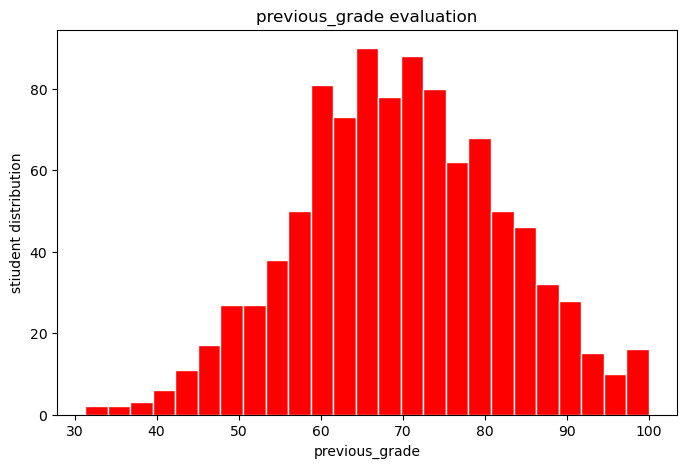

In [55]:
plt.fig=plt.subplots(figsize=(8,5))
plt.hist(df['previous_grade'],bins=25,color='red',edgecolor='white')
plt.title('previous_grade evaluation')
plt.xlabel('previous_grade')
plt.ylabel('stiudent distribution')
plt.show()

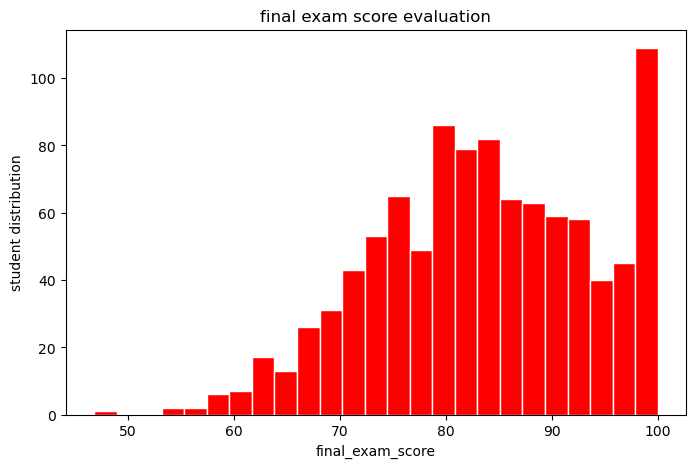

In [56]:
plt.fig=plt.subplots(figsize=(8,5))
plt.hist(df['final_exam_score'],bins=25,color='red',edgecolor='white')
plt.title('final exam score evaluation')
plt.xlabel('final_exam_score')
plt.ylabel('student distribution')
plt.show()

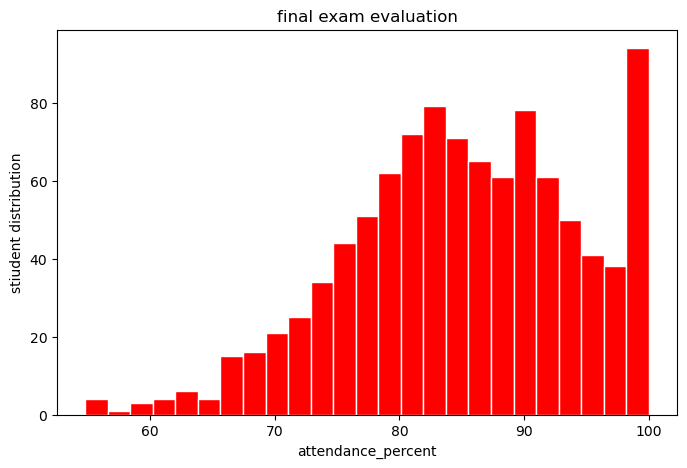

In [25]:

plt.fig=plt.subplots(figsize=(8,5))
#plt.figure(figsize=(8, 5))
plt.hist(df['attendance_percent'],bins=25,color='red',edgecolor='white')
plt.title('final exam evaluation')
#plt.title('Distribution of Student Attendance Rates', fontsize=12, fontweight='bold')
plt.xlabel('attendance_percent')
plt.ylabel('stiudent distribution')
plt.show()

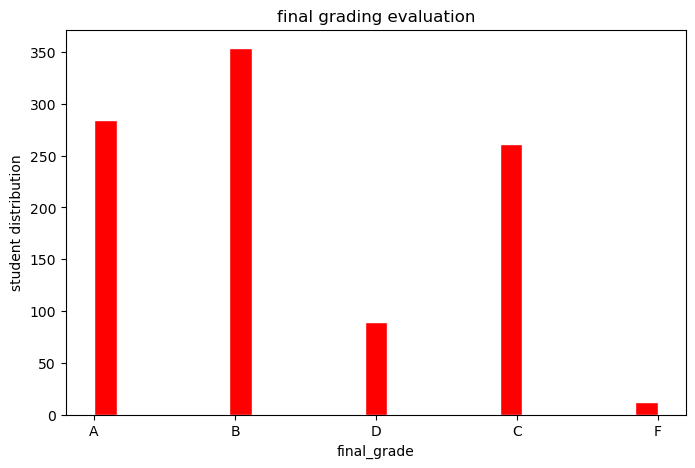

In [57]:
plt.fig=plt.subplots(figsize=(8,5))
plt.hist(df['final_grade'],bins=25,color='red',edgecolor='white')
plt.title('final grading evaluation')
plt.xlabel('final_grade')
plt.ylabel('student distribution')
plt.show()

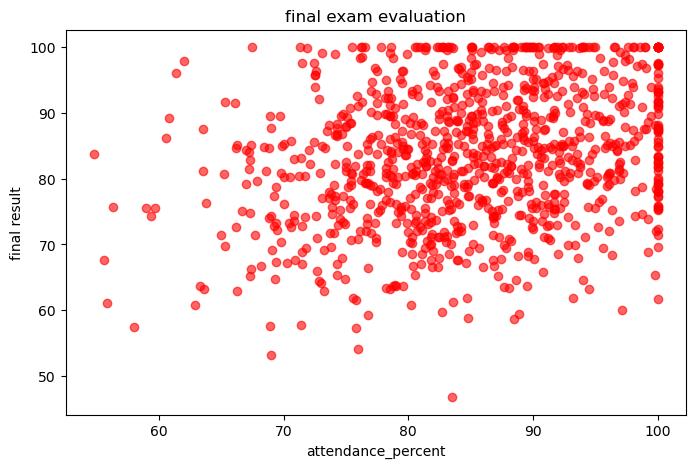

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['attendance_percent'],df['final_exam_score'],color='red',alpha=0.6)
plt.title('final exam evaluation')
plt.xlabel('attendance_percent')
plt.ylabel('final result')
plt.show()

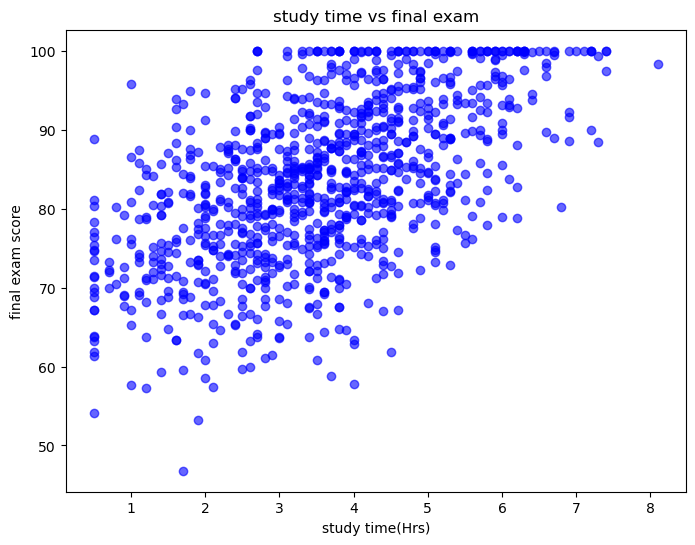

In [61]:
plt.figure(figsize=(8,6))
plt.scatter(df['study_time_hours'],df['final_exam_score'],color='blue',alpha=0.6 )
plt.title('study time vs final exam')
plt.xlabel('study time(Hrs)')
plt.ylabel('final exam score')
plt.show()

In [60]:
# 7. Detailed Statistical Summary (For Coefficients and P-values)
print("\n--- STATSMODELS DETAILED SUMMARY ---")
# Convert booleans to floats if get_dummies output true/false instead of 1/0
x_train_stat = x_train.astype(float)
x_train_stat = sm.add_constant(x_train_stat) # Adds the intercept term
stats_model = sm.OLS(y_train, x_train_stat).fit()
print(stats_model.summary().tables[1])


--- STATSMODELS DETAILED SUMMARY ---
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         41.6672      6.316      6.597      0.000      29.212      54.123
extracurricular_activities     0.4740      1.183      0.401      0.689      -1.860       2.808
study_time_hours               4.0985      0.392     10.448      0.000       3.325       4.872
attendance_percent             0.3106      0.069      4.533      0.000       0.175       0.446


expalin how each factor (x variable) are affecting final result
pvalues and corr
. The R-squared (R²) Score
This number ranges from 0 to 1 (e.g., 0.74). If it says 0.63, it means your model's habits (study_time_hours, attendance_percent, etc.) explain 74% of the variances in student final exam scores.
2. The coef (Coefficients) Column
This is the most actionable part of a linear regression. It shows the exact weight of each habit:study_time_hours coef (e.g., +2.45): For every 1 additional hour a student studies, their final exam score is expected to increase by 2.45 points, assuming everything else stays equal.part_time_job coef (e.g., -3.10): Students holding a part-time job score 3.10 points lower on average than students who do not work.
3. The P>|t| (P-value) Column
This tells you if a student habit is actually statistically meaningful, or just random noise:If the P-value is less than 0.05, that habit is a highly significant predictor of a student's grade.If the P-value is greater than 0.05 (like 0.42), that specific feature (e.g., gender) has no real statistical impact on the final exam score in this dataset, and can be removed.

1. Core Model Performance SummaryThis analysis evaluated the dataset using two distinct mathematical approaches: Logistic Regression (predicting categorized student tiers) and Multiple Linear Regression (predicting the exact numeric final exam score).Logistic Regression Classifier: By consolidating the target grades into 3 distinct performance tiers (Low, Medium, High), the Logistic Regression model achieved an overall accuracy score of 69.0%. This proves that broad academic outcomes are highly predictable based on a student’s underlying study habits and lifestyle habits.Multiple Linear Regression: Attempting to predict the exact, continuous numeric final exam mark using a straight line resulted in a negative R-squared (\(R^{2}\)) score of -0.028.2. Why Linear Regression Broke DownThe negative \(R^{2}\) score is a significant statistical indicator. It reveals that a basic Multiple Linear Regression model performs worse than simply guessing the average score for every student. This breakdown occurred because:Non-Linear Behaviors: Key habits—such as average sleep hours or study time—do not follow a straight linear line. For instance, increasing study time improves scores up to a point, but extreme study hours combined with low sleep eventually damage performance. Linear models fail to capture these curved thresholds.Data Type Vulnerability: Linear regression is highly sensitive to incomplete categorical encoding (such as missing categories in parental education levels), which introduces mathematical noise and distorts the model's coefficients.3. Strategic ConclusionFor this dataset, classification via Logistic Regression is the vastly superior analytical tool compared to Multiple Linear Regression. While trying to calculate an exact exam score creates too much linear error (resulting in an RMSE of 10.45 marks), grouping students into performance tiers allows the algorithm to cleanly isolate and predict success.To identify at-risk students early, educational stakeholders should deploy classification models to flag students slipping into the "Low" performance tier based on their weekly attendance and study hour thresholds.